In [1]:
from scipy.io import loadmat
from pandas import Series
from sklearn.preprocessing import LabelEncoder
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from grouplasso import GroupLassoClassifier

In [2]:
# 加载数据
yale = loadmat('data_aug.mat')
#载入YALE32mat文件的方法，得到的x是一个字典，可以print一下他的shape看一下里面的属性
X = yale['data']

y = yale['labels'].T.flatten()     #将数据展开

In [3]:
# 分组
matrix = np.arange(1024).reshape((32, 32))
n = 8    # 矩阵每行分成几份
Groups = []
m1 = np.split(matrix, n, axis=0)
for m in m1:
    group = np.split(m, n, axis=1)
    Groups = Groups + group

for i in range(len(Groups)):
    Groups[i] = Groups[i].flatten()
# 将特征组列表转换为数组格式
group_array = np.zeros(X.shape[1], dtype=int)
for i, group in enumerate(Groups):
    group_array[group] = i
group_array

array([ 0,  0,  0, ..., 63, 63, 63])

In [4]:
# 初始化Group Lasso模型
model = GroupLassoClassifier(group_ids=group_array, random_state=42, verbose=False, alpha=0.035)

In [5]:
# 训练模型
model.fit(X, y)

/mnt/5468e/ypzhang/.conda/envs/wss_torch/lib/python3.7/site-packages/grouplasso/model.py:297: UserWarning: Failed to converge. Increase the number of iterations.
  warnings.warn("Failed to converge. Increase the "


GroupLassoClassifier(alpha=0.035,
                     group_ids=array([ 0,  0,  0, ..., 63, 63, 63]),
                     random_state=42, verbose=False)

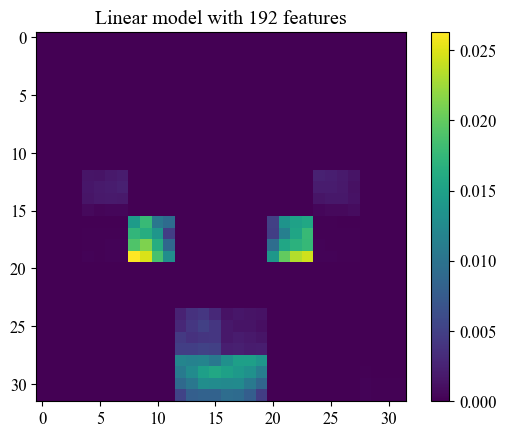

In [6]:
# 输出特征选择结果
import torch
from matplotlib import rcParams
importances = model.coef_
importances = abs(model.coef_) / np.sum(abs(model.coef_))
num = np.count_nonzero(importances)
config = {
    "font.family": 'Times New Roman',
    "font.size": 12
}
rcParams.update(config)
plt.clf()
plt.title(f"Linear model with {num} features")

img = (importances).reshape(32, 32).T
plt.imshow(img)
plt.colorbar()
plt.savefig("figures/yale_grouplasso_selected.pdf", bbox_inches='tight')
plt.show()